# Example climb: save the princess

**Goal**: find a potion which maximizes the probability of a cure while using the least total ingredients

## 1. Notebook setup

### 1.1. Imports

In [1]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from hill_climber import HillClimber

### 1.2. Run configuration

In [2]:
# Hill climber parameters
max_time=1                # Maximum time (in minutes) to run optimization
n_replicas=20             # Number of replicas (workers) in parallel tempering
initial_step_spread=0.5   # Fraction of input range to sample initially
final_step_spread=0.001   # Fraction of input range to sample finally
step_spread_scheme='zeno' # Cooling scheme for step spread
exchange_interval=10000   # Steps between replica exchange attempts
T_max_initial=100         # Replica initial max temperature
T_min_initial=1e-2        # Replica initial min temperature
T_max_final=0             # Replica final max temperature
T_min_final=0             # Replica final min temperature
db_step_interval=1000     # Steps between database writes

# Filename for results database
db_path='../data/princess.db'

# Filename for results checkpoint
output_file = '../data/princess_results.pkl'

# Set True to re-run optimization, False to load checkpoint from disk
run_optimization = True

# Set random seed for reproducibility
np.random.seed(315)

## 2. Potion model

### 2.1. Data preparation

In [3]:
df = pd.read_csv('https://gperdrizet.github.io/FSA_devops/assets/data/unit3/Cure_the_princess.csv')

train_df, test_df = train_test_split(df)
train_df.info()    

<class 'pandas.core.frame.DataFrame'>
Index: 1753 entries, 2137 to 611
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Phoenix Feather  1753 non-null   float64
 1   Unicorn Horn     1753 non-null   float64
 2   Dragon's Blood   1753 non-null   float64
 3   Mermaid Tears    1753 non-null   float64
 4   Fairy Dust       1753 non-null   float64
 5   Goblin Toes      1753 non-null   float64
 6   Witch's Brew     1753 non-null   float64
 7   Griffin Claw     1753 non-null   float64
 8   Troll Hair       1753 non-null   float64
 9   Kraken Ink       1753 non-null   float64
 10  Minotaur Horn    1753 non-null   float64
 11  Basilisk Scale   1753 non-null   float64
 12  Chimera Fang     1753 non-null   float64
 13  Cured            1753 non-null   int64  
dtypes: float64(13), int64(1)
memory usage: 205.4 KB


### 2.2. Model training

In [4]:
model = GradientBoostingClassifier()
_ = model.fit(train_df.drop(columns=['Cured']), train_df['Cured'])

### 2.3. Model evaluation

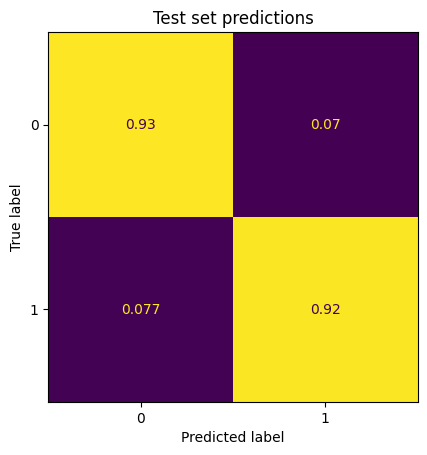

In [5]:
predictions = model.predict(test_df.drop(columns=['Cured']))

ConfusionMatrixDisplay.from_predictions(
    test_df['Cured'],
    predictions,
    normalize='true',
    colorbar=False
)

plt.title('Test set predictions')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

### 2.4. Retrain with complete dataset

In [6]:
_ = model.fit(df.drop(columns=['Cured']), df['Cured'])

## 3. Find best potion

### 3.1. Starting potion

In [7]:
# Get max ingredient values from the dataset
max_values = df.drop(columns='Cured').describe().loc['max']
max_values

Phoenix Feather    42.1
Unicorn Horn       34.1
Dragon's Blood     40.8
Mermaid Tears      35.8
Fairy Dust         40.4
Goblin Toes        37.8
Witch's Brew       37.3
Griffin Claw       39.4
Troll Hair         44.8
Kraken Ink         39.5
Minotaur Horn      33.7
Basilisk Scale     42.0
Chimera Fang       37.8
Name: max, dtype: float64

In [8]:
# Create a random starting potion where each ingredient is between 0 and its max value
starting_potion = {}

for feature, value in max_values.items():
    starting_potion[feature] = [np.random.uniform(0, max_values.loc[feature])]

starting_potion_df = pd.DataFrame(starting_potion)
starting_potion_df.transpose()

,0
Phoenix Feather,32.316773
Unicorn Horn,2.974719
Dragon's Blood,25.788348
Mermaid Tears,19.179930
Fairy Dust,33.715806
Goblin Toes,34.298547
Witch's Brew,23.000576
Griffin Claw,35.818569
Troll Hair,21.774855
Kraken Ink,12.140236


### 3.2. Objective function

In [9]:
# Get total max value sum for all ingredients. Will be used to calculate a
# penalty term based on total ingredient values in the potion.
total_max_value = max_values.sum()
print(f'Combined max value for all ingredients: {total_max_value}')

Combined max value for all ingredients: 505.5


In [10]:
# Get feature names
features = max_values.index.tolist()
print(f'Features: {features}')

Features: ['Phoenix Feather', 'Unicorn Horn', "Dragon's Blood", 'Mermaid Tears', 'Fairy Dust', 'Goblin Toes', "Witch's Brew", 'Griffin Claw', 'Troll Hair', 'Kraken Ink', 'Minotaur Horn', 'Basilisk Scale', 'Chimera Fang']


In [11]:
def score_potion(*args):

    global features
    global model
    global total_max_value

    # Stack columns horizontally to create DataFrame
    potion_df = pd.DataFrame(
        np.column_stack(args),
        columns=features
    )

    # Predict cure probability
    cure_probability = model.predict_proba(potion_df)[0, 1]

    # Calculate total ingredient penalty
    ingredient_sum = potion_df.sum(axis=1).values[0]
    penalty = ingredient_sum / total_max_value

    # Calculate objective value
    objective = cure_probability - 2 * penalty
    
    # Compile metrics
    metrics = {
        'Cure probability': cure_probability,
        'Ingredient penalty': penalty
    }

    return metrics, objective

### 3.3. Hill climb optimization

In [12]:
if run_optimization:

    # Create HillClimber instance
    climber = HillClimber(
        data=starting_potion_df,
        objective_func=score_potion,
        initial_step_spread=initial_step_spread,
        final_step_spread=final_step_spread,
        step_spread_scheme=step_spread_scheme,
        T_max_initial=T_max_initial,
        T_min_initial=T_min_initial,
        T_max_final=T_max_final,
        T_min_final=T_min_final,
        exchange_interval=exchange_interval,
        db_step_interval=db_step_interval,
        max_time=max_time,
        n_replicas=n_replicas,
        db_path=db_path,
        checkpoint_file=output_file
    )

    # Create bounds tuple for each feature from 0 to max_values
    lower_bounds = np.zeros(len(max_values))
    upper_bounds = max_values.values

    # Override the bounds that were auto-calculated from the single-row data
    climber.bounds = (lower_bounds, upper_bounds)

    # Run optimization (step_spread_absolute will be calculated using new bounds)
    best_data = climber.climb()

HillClimber Configuration

Data shape:           (1, 13)
Optimization mode:    maximize
Max runtime:          1 minutes

Temperature settings:
  T_min_initial:       0.01
  T_max_initial:       100
  T_min_final:         1e-15
  T_max_final:         1e-15
  Ladder spacing:      geometric
  Cooling schedule:    geometric

Replica exchange:
  Number of replicas: 20
  Exchange interval:  10000 steps
  Exchange strategy:  even_odd
  Worker processes:   20

Perturbation settings:
  Initial step spread: 0.5 (fraction of range)
  Final step spread:   0.001 (fraction at end of run)
  Cooling scheme:      zeno
  Perturb fraction:    0.001

Database settings:
  Enabled:            True
  Path:               ../data/princess.db
  Step interval:      1000

Checkpointing:        ../data/princess_results.pkl (every 1 batch)


### 4. Results

In [13]:
# If we just re-ran the optimization, collect results from the climber
if run_optimization:

    # Combine all replicas into a single DataFrame
    results_df = pd.concat(climber.get_replicas(), axis=0)

# Otherwise, load from saved results
else:

    # Load the results checkpoint
    try:
        with open(output_file, 'rb') as f:
            results = pickle.load(f)

        # Collect best data from each replica
        replicas = []

        for replica_data in results['replicas']:
            replicas.append(replica_data['best_data'])

        # Combine all replicas into a single DataFrame
        results_df = pd.concat(replicas, axis=0)

    except FileNotFoundError:
        print(f'Error: checkpoint file not found. Please run the optimization by setting run_optimization = True in the run configuration cell.')
    
        results_df = pd.DataFrame()

results_df.head()

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang
0,0.028667,0.045895,0.030265,0.104733,0.015325,0.019379,0.051101,0.026793,20.053372,0.009299,0.000849,0.058295,0.049552
0,0.078618,0.017369,0.002311,0.049889,0.097178,0.014565,8.302492,0.000350,11.858588,0.013084,0.018316,0.023562,0.032993
0,0.008963,0.010241,0.018429,0.012547,0.004150,0.001576,8.358929,0.069841,11.904285,0.010867,0.015293,0.004308,0.005805
0,0.001983,0.005206,0.025754,0.004671,0.124811,0.007053,25.625474,0.052672,0.013680,0.044014,0.017149,0.147786,0.049869
0,0.005416,0.039376,0.052777,0.029948,0.015846,0.056077,8.348990,0.011420,11.914665,0.148736,0.004466,0.034193,0.004679


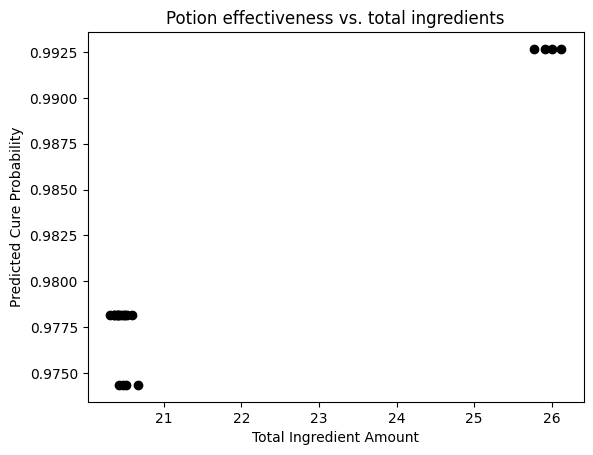

Best cure probability: 0.9927
Lowest ingredient sum: 20.31
Best objective (cure - penalty): 0.9417


In [14]:
predictions = model.predict_proba(results_df)[:, 1]
ingredient_sums = results_df.sum(axis=1)

# Create scatter plot
plt.title('Potion effectiveness vs. total ingredients')
plt.scatter(ingredient_sums, predictions, c='black')
plt.xlabel('Total Ingredient Amount')
plt.ylabel('Predicted Cure Probability')
plt.show()

# Print summary statistics
print(f'Best cure probability: {predictions.max():.4f}')
print(f'Lowest ingredient sum: {ingredient_sums.min():.2f}')
print(f'Best objective (cure - penalty): {(predictions - ingredient_sums/total_max_value).max():.4f}')